## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga de datos

In [2]:
df = pd.read_csv("../../Data/clean_data_nulos_09-03-2026.csv")
df

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,first_review_date,last_review_date,number_of_reviews,reviews_per_month,city,insert_date,price_missing,reviews 80+
0,11964,Private room,400.0,True,7,20,40,130,97.0,2010-01-02,2017-09-05,78,0.76,Malaga,2018-07-31,False,True
1,21853,Private room,170.0,True,0,0,0,162,92.0,2014-10-10,2018-07-15,33,0.52,Madrid,2020-01-10,False,True
2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,2011-01-05,2019-07-22,148,1.44,Sevilla,2019-07-29,False,True
3,35379,Private room,400.0,True,9,23,49,300,94.0,2012-03-13,2020-01-04,292,3.10,Barcelona,2020-01-10,False,True
4,35801,Private room,900.0,True,0,19,49,312,97.0,2011-07-08,2018-08-08,36,0.39,Girona,2019-02-19,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6728,27237828,Entire home/apt,1500.0,True,22,47,77,78,100.0,2018-08-26,2018-08-26,1,7.60,Girona,2018-08-30,False,True
6729,27241318,Entire home/apt,3130.0,True,26,37,37,243,100.0,2020-03-13,2020-03-13,1,0.74,Mallorca,2020-04-23,False,True
6730,27244243,Entire home/apt,990.0,True,24,40,40,40,NaN,NaN,NaN,0,NaN,Girona,2018-08-30,False,NaN
6731,27244794,Entire home/apt,720.0,True,0,0,0,0,100.0,2018-09-23,2018-09-23,1,0.07,Girona,2019-12-31,False,True


## Generales

- Total alojamientos general y disponibles
- Avg Price
- Avg rating (scores_rating)
- Ratio de ocupación estimada

In [3]:
# Total de alojamientos

total_alojamientos = len(df)

# Total de alojamientos disponibles
disponibles = df[df['has_availability'] == True].shape[0]

#Promedio de precio general
AVGprice=round((df['price'].mean()),2)

print(f"Total de alojamientos: {total_alojamientos}")
print(f"Alojamientos disponibles: {disponibles}")

print(f"AVGprice: {AVGprice}")

avg_rating = df["review_scores_rating"].dropna().mean()
print(f"Avg rating (all scores): {avg_rating:.2f}")


Total de alojamientos: 6733
Alojamientos disponibles: 6199
AVGprice: 1010.93
Avg rating (all scores): 92.01


## Marketing

- Precio medio general - por room type
- Precio medio general
- Avg number_of_reviews (total reviews = reservas aprox)

In [4]:


#Precio mediano gengeral
medianprice=round((df['price'].median()),2)
#Promedio de reviews
AVGreviews=round((df['number_of_reviews'].mean()))


print(f"Median price: {medianprice}")

print(f"AVGreviews: {AVGreviews}")

Median price: 750.0
AVGreviews: 34


In [5]:
# Precio medio general - por room type
df.groupby('room_type')[['price']].mean().round(2)

,price
room_type,
Entire home/apt,1241.67
Hotel room,1063.03
Private room,448.24
Shared room,324.15


Text(0, 0.5, 'Precio medio')

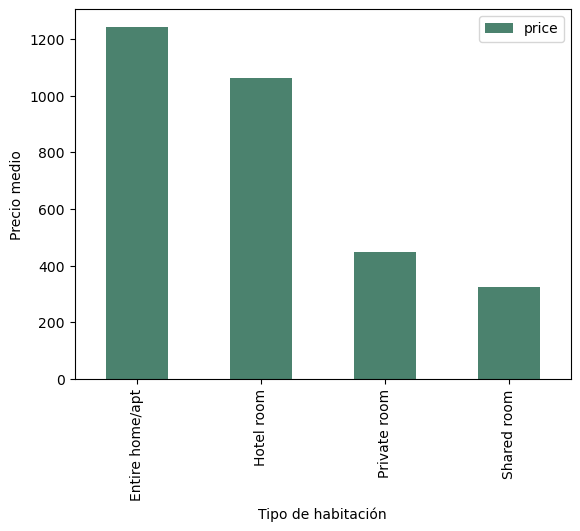

In [6]:

# Grafico importe medio por romm type
df.groupby('room_type')[['price']].mean().sort_values(by='price',ascending=False).plot.bar(color='#4b826e')
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio medio")

## Cliente

Average rating general

Average reviews per month

In [7]:
# Filtro para el cálculo. Filtramos SOLO los 2 valores infinitos para poder calcular reviews_per_month
filas_infinitas = df[np.isinf(df['reviews_per_month'])]

# KPI 1 — Average rating
avg_rating = df["review_scores_rating"].dropna().mean()

# KPI 2 — Average reviews per month
avg_reviews_month = df["reviews_per_month"].drop(filas_infinitas.index).mean()

print("KPI RESULTS")
print("---------------------")
print(f"Avg rating (all scores): {avg_rating:.2f}")
print(f"Avg reviews per month: {avg_reviews_month:.2f}")

KPI RESULTS
---------------------
Avg rating (all scores): 92.01
Avg reviews per month: 1.46


** KPI finales de Experiencia del cliente

In [8]:
satisfaction_items = {
    "accuracy": df["review_scores_accuracy"].mean(),
    "cleanliness": df["review_scores_cleanliness"].mean(),
    "checkin": df["review_scores_checkin"].mean(),
    "communication": df["review_scores_communication"].mean(),
    "location": df["review_scores_location"].mean()
}

# Convertir a dataframe
satisfaction_df = pd.DataFrame.from_dict(
    satisfaction_items,
    orient="index",
    columns=["avg_score"]
)

# Ítem con mayor satisfacción
max_item = satisfaction_df["avg_score"].idxmax()
max_value = satisfaction_df["avg_score"].max()

print("Item with highest satisfaction:")
print(max_item, round(max_value,2))

print("\nAverage satisfaction by item:")
print(satisfaction_df)

KeyError: 'review_scores_accuracy'

## Operaciones
- Tasa de ocupación mensual
- Ciudad con mayor ocupación (mensual)

#### Preparación del dataset

In [ ]:
df_operaciones = df.copy()

availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

# apartamentos totalmente ocupados
df_operaciones["fully_booked"] = (df_operaciones[availability_cols] == 0).all(axis=1)


#### Variables derivadas (ocupación)

In [ ]:
df_operaciones["occ_30"] = (30 - df_operaciones["availability_30"]) / 30
df_operaciones["occ_60"] = (60 - df_operaciones["availability_60"]) / 60
df_operaciones["occ_90"] = (90 - df_operaciones["availability_90"]) / 90
df_operaciones["occ_365"] = (365 - df_operaciones["availability_365"]) / 365

occupancy_cols = ["occ_30", "occ_60", "occ_90", "occ_365"]

# días ocupados (para KPI principal)
df_operaciones["occupied_days_30"] = 30 - df_operaciones["availability_30"]

#### KPI globales operaciones

In [ ]:
# inventario total
total_apartments = df_operaciones["apartment_id"].nunique()

# inventario activo
active_apartments = df_operaciones["has_availability"].sum()

# alojamientos con disponibilidad en próximos 30 días
available_30 = (df_operaciones["availability_30"] > 0).sum()

# ratio de oferta disponible
available_supply_ratio = round((available_30 / active_apartments) * 100, 2)

# apartamentos completamente reservados
fully_booked_active = df_operaciones[
    (df_operaciones["fully_booked"]) &
    (df_operaciones["has_availability"])
].shape[0]

# tasa de ocupación mensual (KPI principal)
monthly_occupancy_rate = round(
    (df_operaciones["occupied_days_30"].sum() /
     (active_apartments * 30)) * 100,
    2
)

# ocupación promedio por horizonte temporal
occupancy_rates = (df_operaciones[occupancy_cols].mean() * 100).round(2)

#### KPI por segmento

In [ ]:
# ocupación por ciudad
occupancy_by_city = (
    df_operaciones
    .groupby("city")[occupancy_cols]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

# ciudad con mayor ocupación mensual
top_city = (
    occupancy_by_city
    .sort_values("occ_30", ascending=False)
    .iloc[0]
)

# oferta disponible por ciudad
supply_by_city = (
    df_operaciones[df_operaciones["availability_30"] > 0]
    .groupby("city")["apartment_id"]
    .nunique()
    .reset_index(name="available_listings")
    .sort_values(by="available_listings", ascending=False)
)

# oferta disponible por tipo de habitación
supply_by_room = (
    df_operaciones[df_operaciones["availability_30"] > 0]
    .groupby("room_type")["apartment_id"]
    .nunique()
    .reset_index(name="available_listings")
    .sort_values(by="available_listings", ascending=False)
)


#### Tabla final de KPI operaciones

In [ ]:
kpi_operaciones = {
    "total_apartments": int(total_apartments),
    "active_apartments": int(active_apartments),
    "available_next_30_days": int(available_30),
    "available_supply_%": float(available_supply_ratio),
    "fully_booked_active": int(fully_booked_active),
    "monthly_occupancy_%": float(monthly_occupancy_rate),
    "yearly_occupancy_%": float(occupancy_rates["occ_365"]),
    "top_city_by_occupancy": top_city["city"],
    "top_city_occupancy_%": float(top_city["occ_30"])
}

kpi_operaciones_df = pd.DataFrame(
    list(kpi_operaciones.items()),
    columns=["KPI", "Valor"]
)

kpi_operaciones_df

,KPI,Valor
0,total_apartments,6733
1,active_apartments,6199
2,available_next_30_days,4755
3,available_supply_%,76.71
4,fully_booked_active,822
5,monthly_occupancy_%,64.38
6,yearly_occupancy_%,48.68
7,top_city_by_occupancy,Madrid
8,top_city_occupancy_%,65.37
